In [1]:
import sys
print(sys.executable)

/mnt/c/Users/ssait/Desktop/learnings/python-practice-jupyter/venv/bin/python


In [2]:
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
customer_data = pd.read_csv("/mnt/c/Users/ssait/Downloads/Credit_Card.csv")

In [5]:
df = customer_data.copy()

In [6]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [7]:
df.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [8]:
df.columns = [c.replace(" ","_") for c in df.columns]

In [9]:
df.shape

(660, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer_Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [11]:
df.isnull().sum()

Sl_No                  0
Customer_Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [12]:
df.nunique()

Sl_No                  660
Customer_Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

In [13]:
data_grouped = df.groupby("Customer_Key").count()

for i in data_grouped.loc[data_grouped.Sl_No >= 2].index:
    display(df.loc[df.Customer_Key == i])

,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2


,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
4,5,47437,100000,6,0,12,3
332,333,47437,17000,7,3,1,0


,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2


,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2


,Sl_No,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


In [14]:
df.drop(columns=["Sl_No", "Customer_Key"], inplace=True, errors='ignore')

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.0,18000.0,48000.0,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.0,5.0,6.0,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.0,2.0,4.0,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.0,2.0,4.0,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.0,3.0,5.0,10.0


Exploratory Data Analysis

In [16]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios":(0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette='winter'
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color='green', linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )


In [17]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """
    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))
    
    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette='Paired',
        order=data[feature].value_counts().index[:n].sort_values()
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0,5),
            textcoords="offset points",
        )

plt.show()


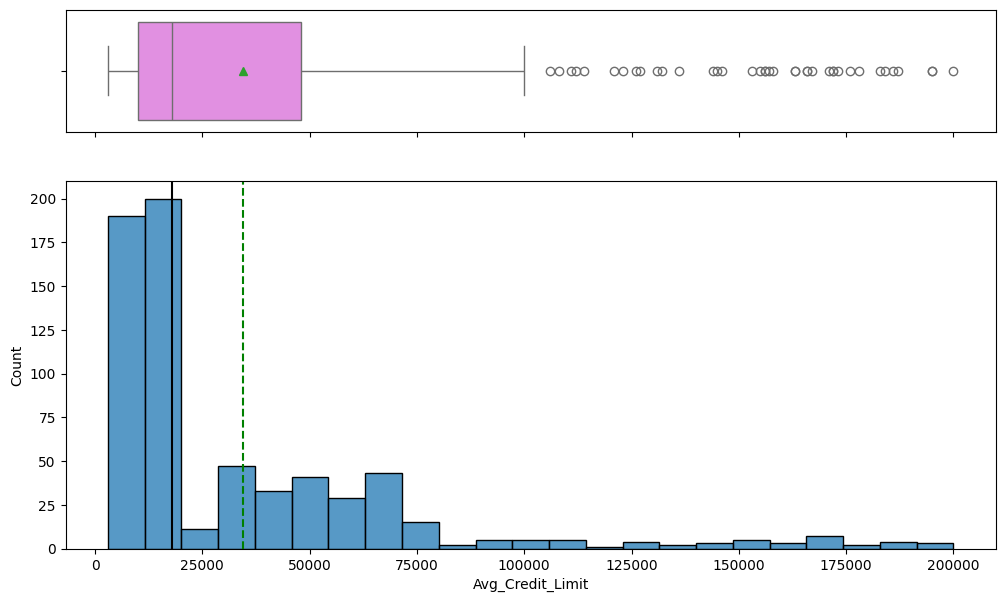

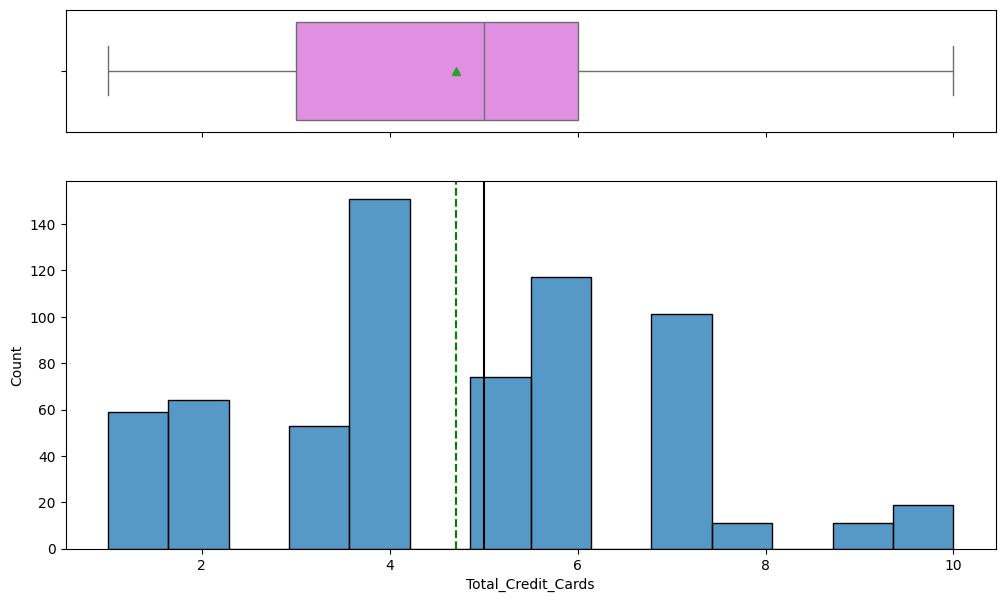

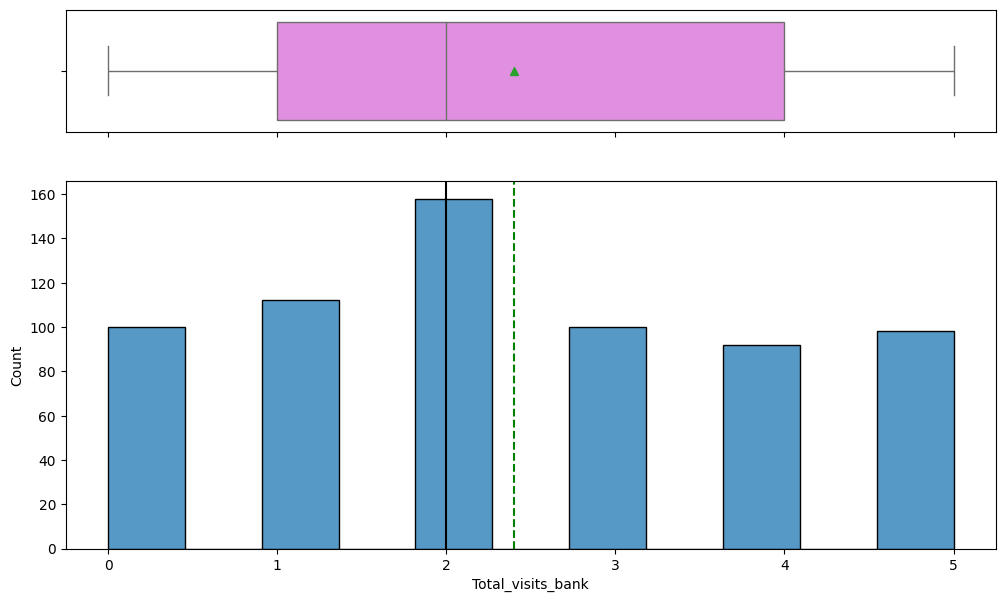

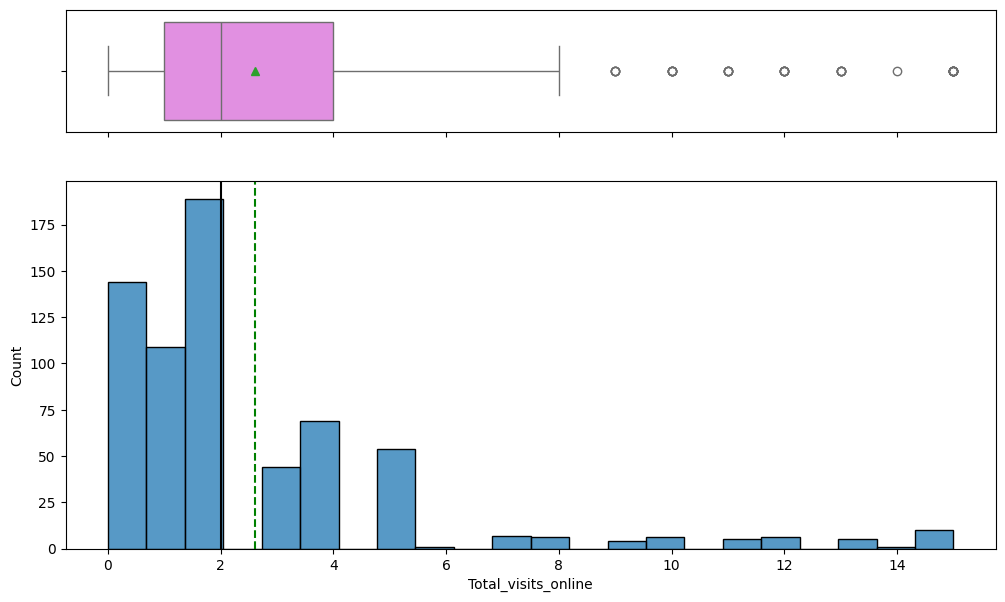

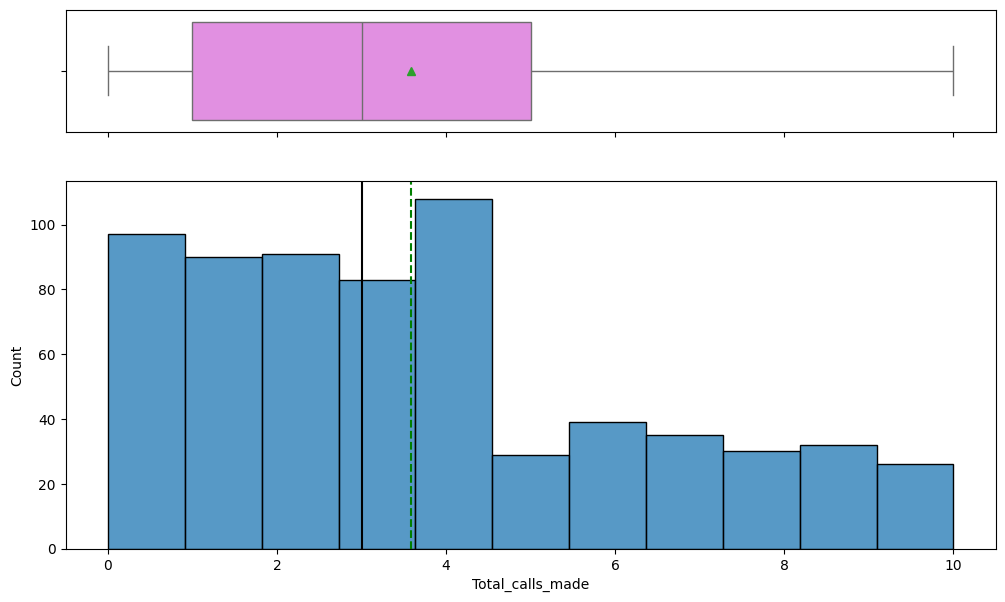

In [18]:
for col in df.columns:
    histogram_boxplot(df, col)

In [19]:
df.columns

Index(['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made'],
      dtype='object')

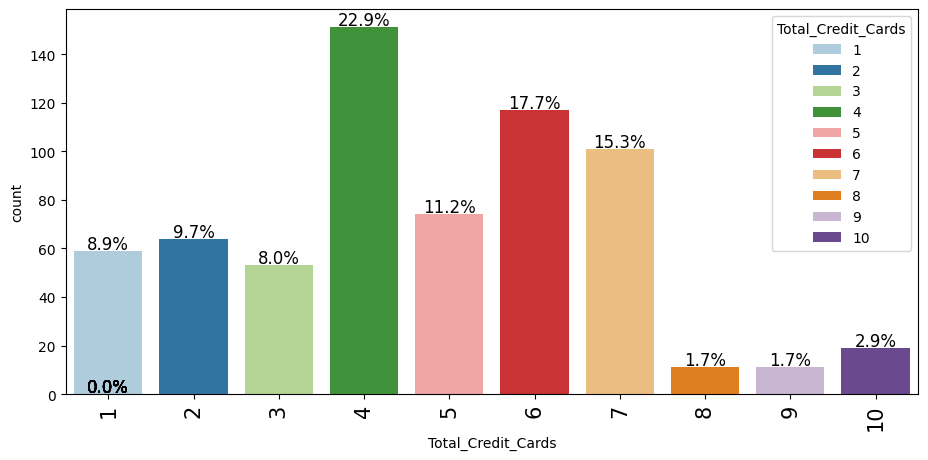

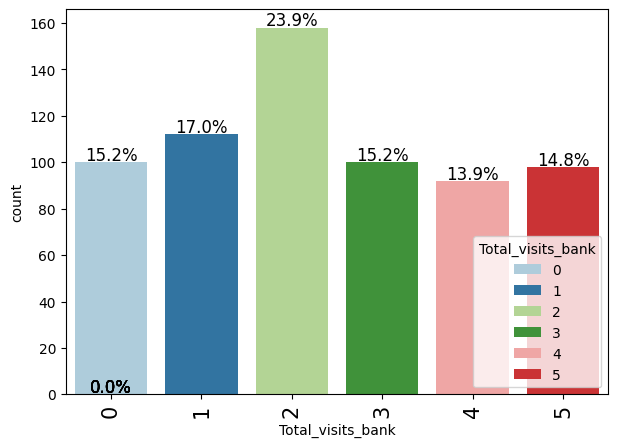

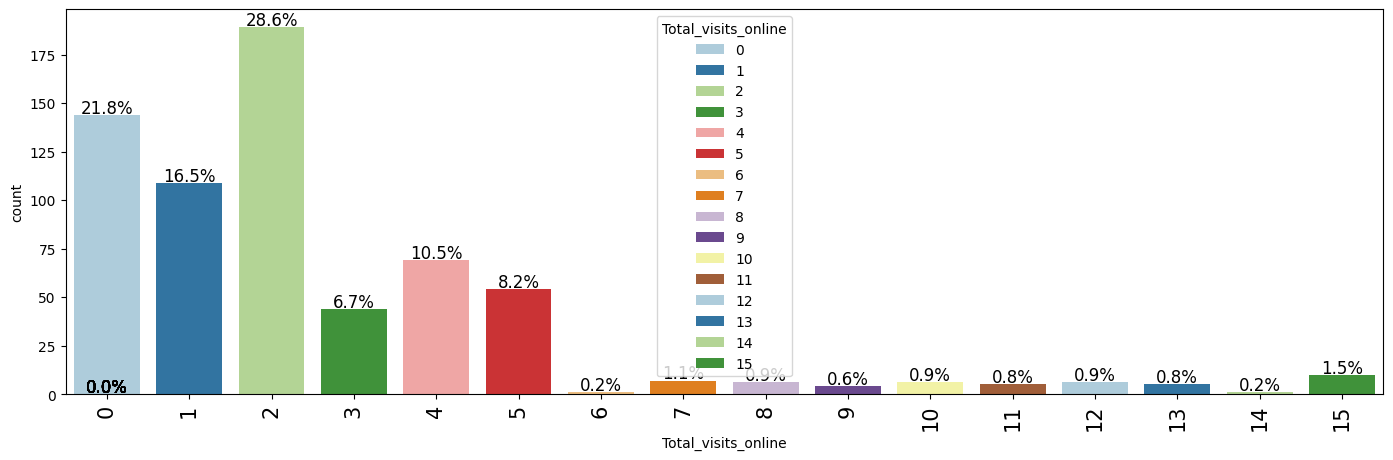

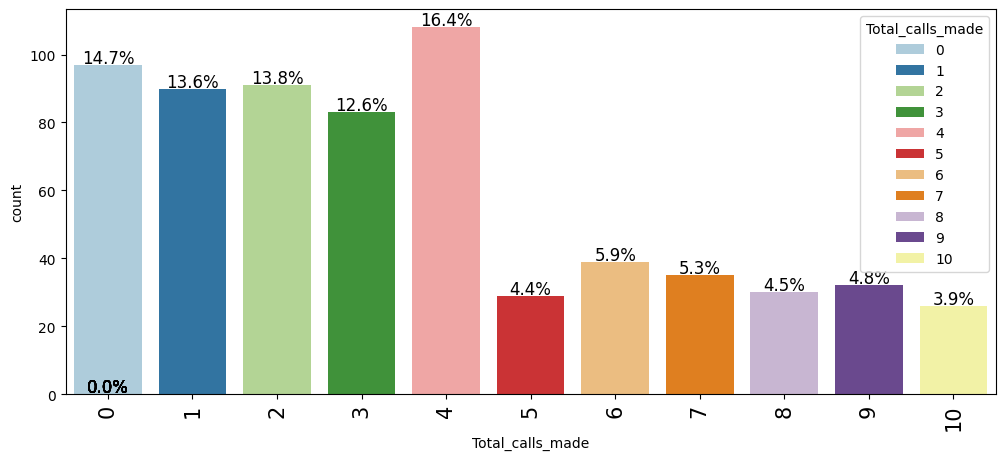

In [20]:
for col in df.columns.tolist()[1:]:
    labeled_barplot(df, col, perc=True)

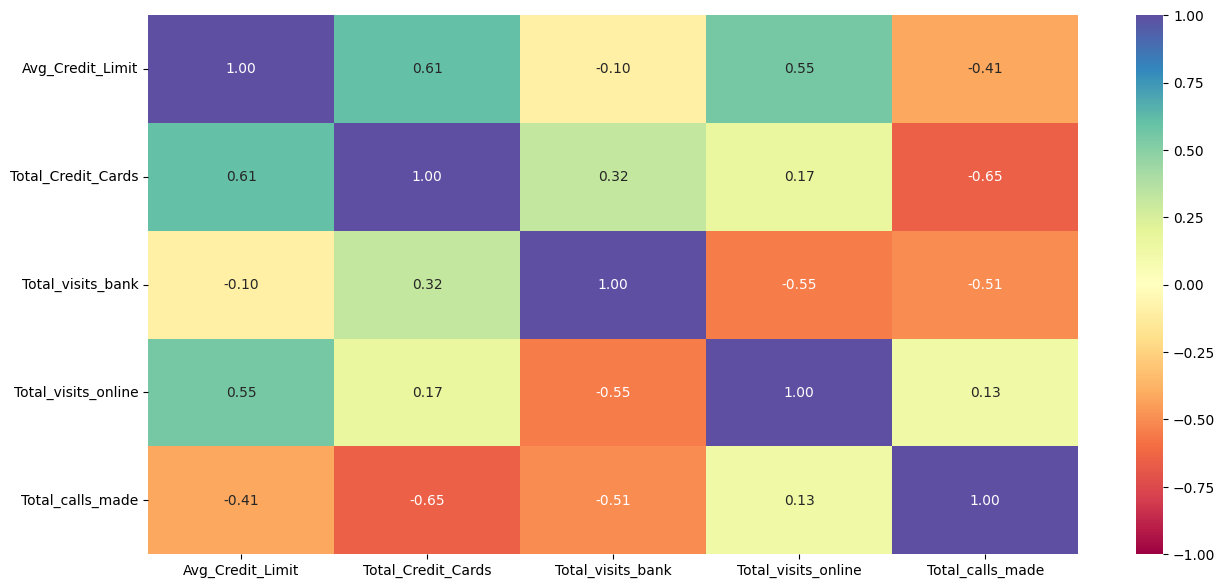

In [21]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

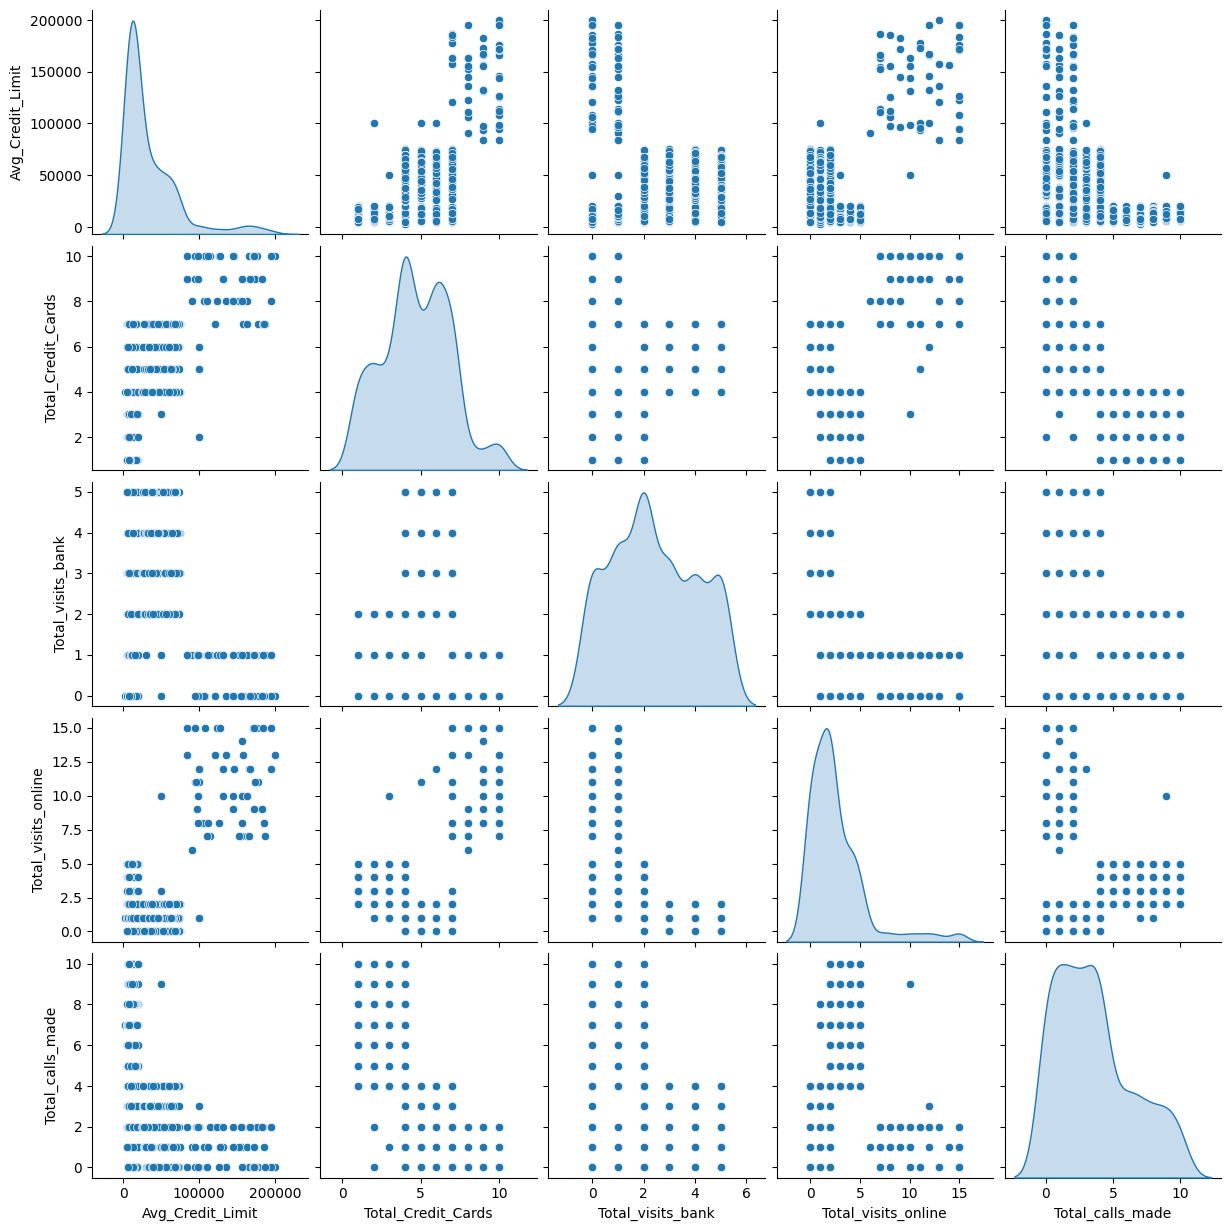

In [22]:
sns.pairplot(data=df, diag_kind='kde')
plt.show()

In [23]:
fig =px.scatter_3d(df, x='Total_visits_bank', y='Total_visits_online', z='Total_calls_made')
fig.show()

Data Preprocessing

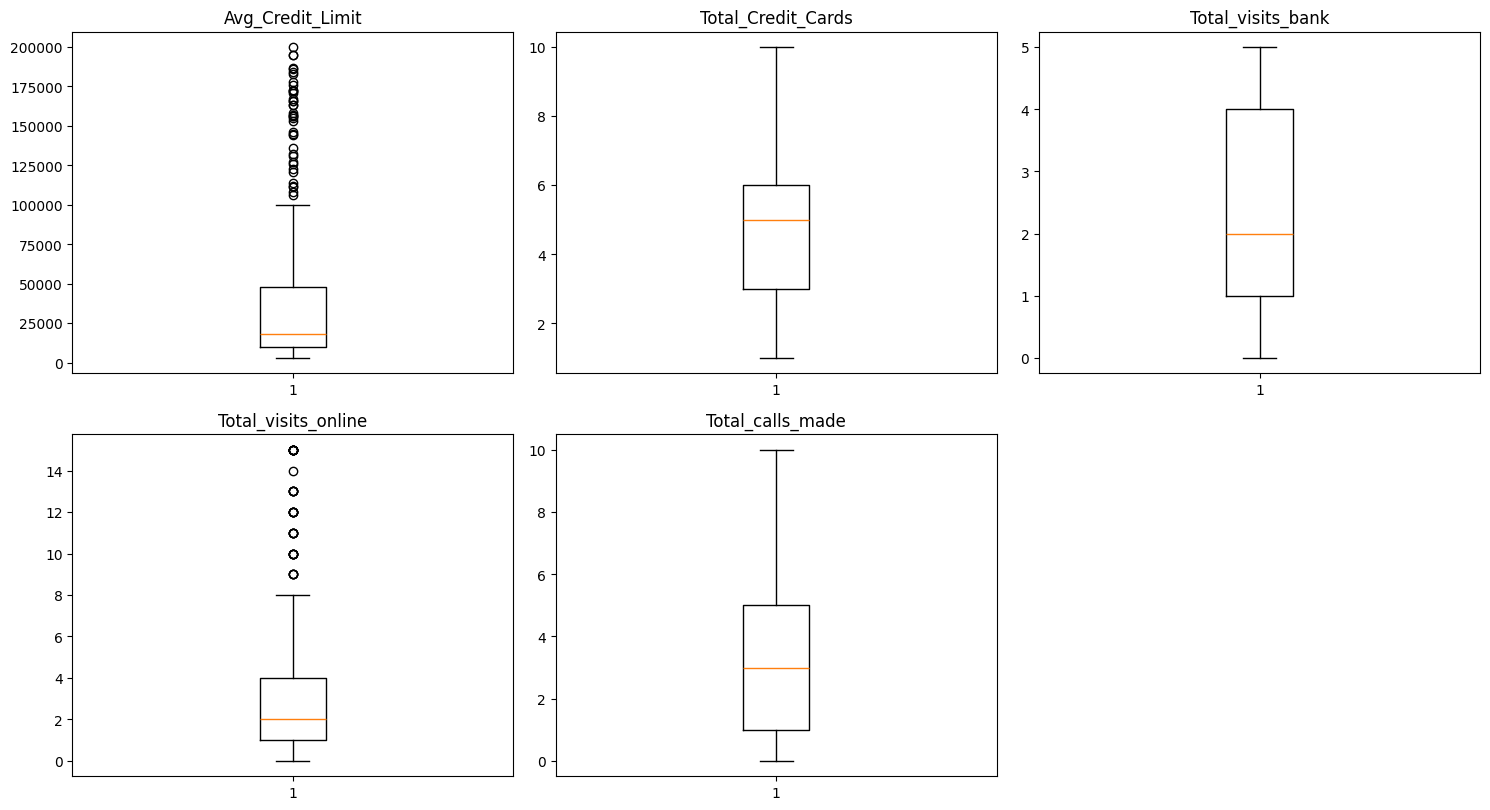

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i+1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Scaling

In [25]:
scaler = StandardScaler()
subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [26]:
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

Dimensionality Reduction and Visualization using t-SNE

In [28]:
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS)

tsne_reduced_data = tsne.fit_transform(subset_scaled_df)
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1", "Feature 2"]))


In [30]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,7.943978,1.848176
1,-39.736549,12.263881
2,11.586137,9.645995
3,-0.051764,-3.928401
4,8.549613,37.941483


<Axes: xlabel='Feature 1', ylabel='Feature 2'>

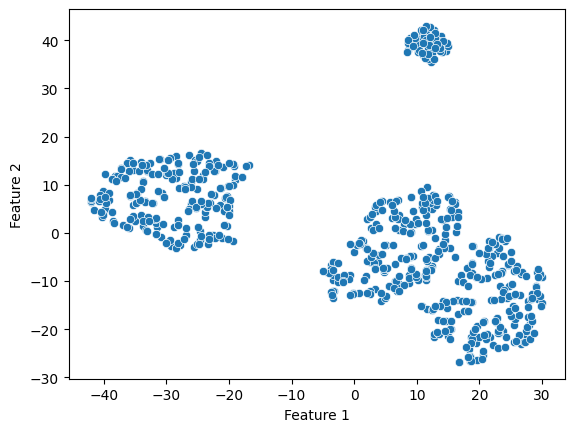

In [32]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2")

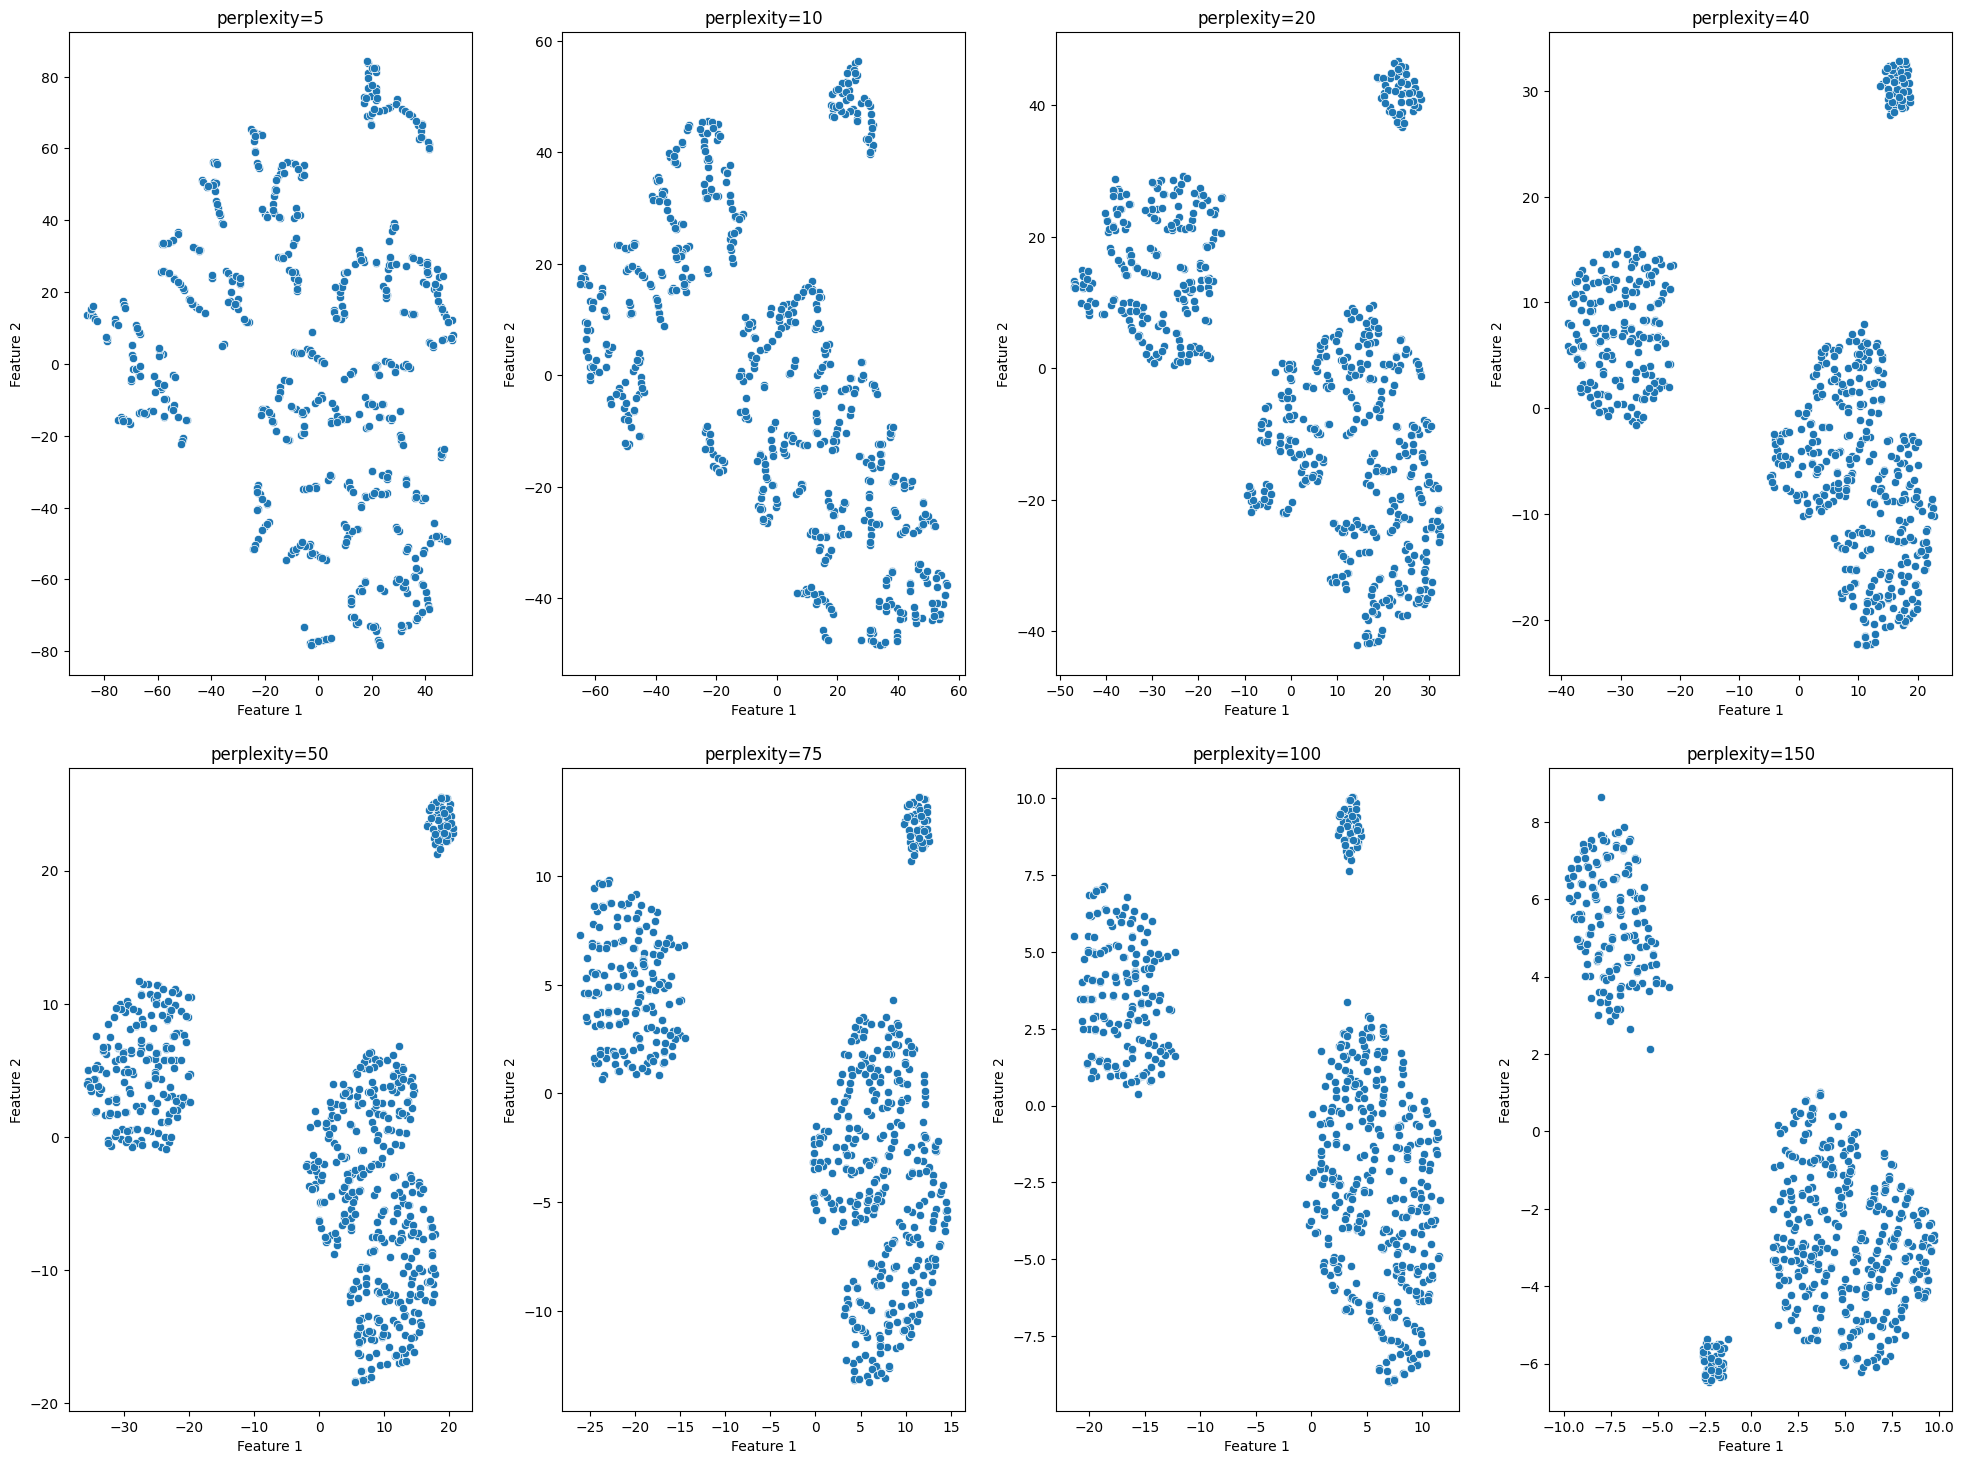

In [34]:
perplexities = [5, 10, 20, 40, 50, 75, 100, 150]

plt.figure(figsize=(20, 15))

for i in range(len(perplexities)):
    tsne=TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=RS)
    X_red = tsne.fit_transform(subset_scaled_df)
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])

    plt.subplot(2, 4, i+1)

    plt.title("perplexity=" + str(perplexities[i]))
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

In [36]:
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

tsne_reduced_data =tsne.fit_transform(subset_scaled_df)

tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1", "Feature 2"]))
tsne_2d_data.head()

,Feature 1,Feature 2
0,8.494344,2.035531
1,-34.313858,7.572145
2,12.311473,6.836919
3,2.070791,3.930377
4,16.694479,23.532461


In [37]:
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

tsne_reduced_data =tsne.fit_transform(subset_scaled_df)

tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1", "Feature 2", "Feature 3"]))

In [39]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,3.041842,1.140112,4.131837
1,-12.759686,2.973345,2.024136
2,2.379192,2.324488,-0.494974
3,-0.003296,0.424792,-0.008586
4,6.760740,9.645950,0.293652


In [41]:
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3')
fig.show()

In [42]:
k_means_df = subset_scaled_df.copy()

In [45]:
clusters = range(2, 11)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_

    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 2 	wcss: 2040.9898164784947
Number of Clusters: 3 	wcss: 933.0437490000536
Number of Clusters: 4 	wcss: 780.7736895551768
Number of Clusters: 5 	wcss: 729.7775796939322
Number of Clusters: 6 	wcss: 654.2363335547993
Number of Clusters: 7 	wcss: 621.1900732083068
Number of Clusters: 8 	wcss: 576.1657087694117
Number of Clusters: 9 	wcss: 553.8059084968588
Number of Clusters: 10 	wcss: 534.4071355047333


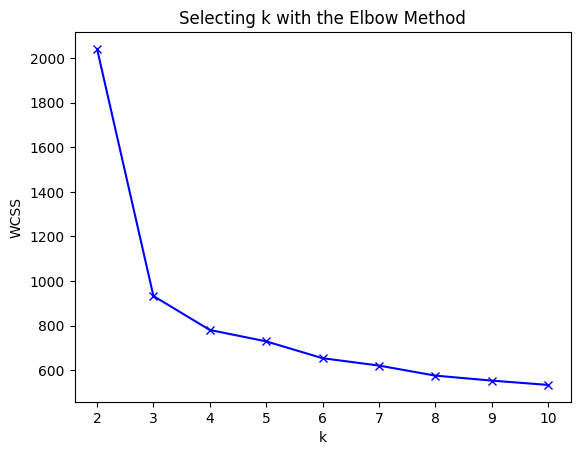

In [47]:
plt.plot(clusters, WCSS, "bx-")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method")
plt.show()

In [49]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=RS)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.41842496663215445)
For n_clusters = 3, the silhouette score is 0.5157182558881063)
For n_clusters = 4, the silhouette score is 0.3556670619372605)
For n_clusters = 5, the silhouette score is 0.3280708837264839)
For n_clusters = 6, the silhouette score is 0.24847126878075285)
For n_clusters = 7, the silhouette score is 0.22386857007469432)
For n_clusters = 8, the silhouette score is 0.2424290733851475)
For n_clusters = 9, the silhouette score is 0.23602958161384577)


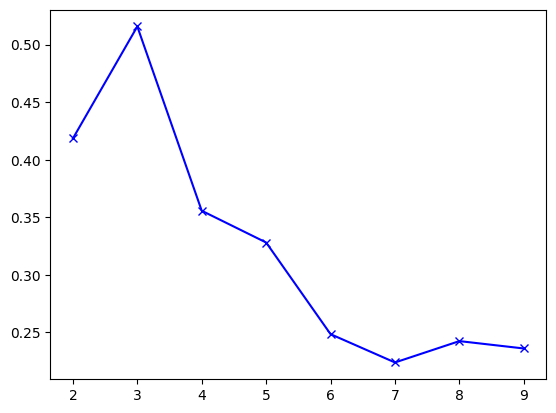

In [51]:
plt.plot(cluster_list, sil_score, "bx-")
plt.show()

In [53]:
kmeans = KMeans(n_clusters=3, random_state=RS)
kmeans.fit(k_means_df)

KMeans(n_clusters=3, random_state=0)

In [54]:
df1 = df.copy()

k_means_df["K_means_segments"] = kmeans.labels_
df1["K_means_segments"] = kmeans.labels_
tsne_2d_data["K_means_segments"] = kmeans.labels_
tsne_3d_data["K_means_segments"] = kmeans.labels_

Visualizing Final Clusters

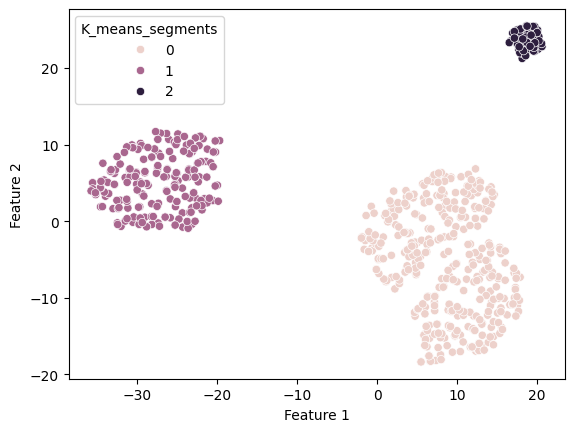

In [57]:
# visualizing the final cluster using t-SNE 2D
sns.scatterplot(data=tsne_2d_data, x='Feature 1', y='Feature 2', hue='K_means_segments');

In [59]:
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3',color='K_means_segments')
fig.show()

Cluster Characteristics

In [60]:
km_cluster_profile = df1.groupby("K_means_segments").mean()

In [62]:
km_cluster_profile["count_in_each_segment"] = (
    df1.select_dtypes(include=np.number).groupby("K_means_segments")["Avg_Credit_Limit"].count()
)

In [63]:
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
K_means_segments,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


In [64]:
num_col = df1.select_dtypes(include=np.number).columns.to_list()

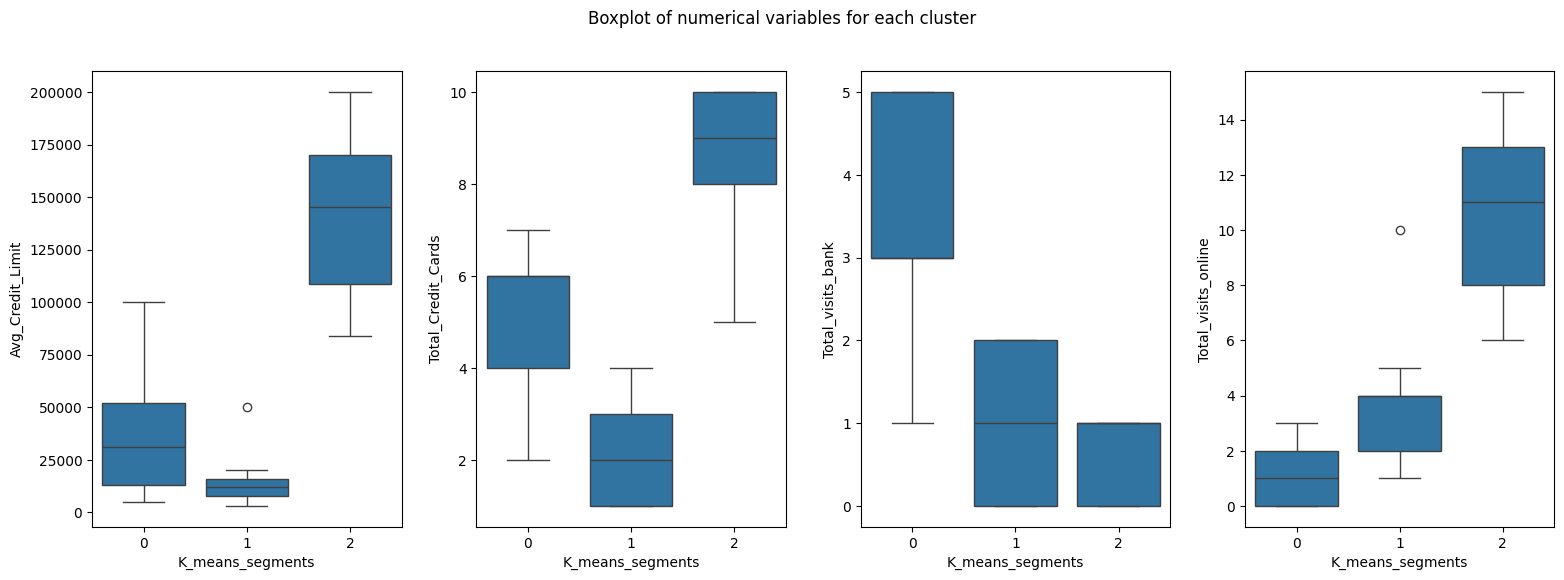

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle("Boxplot of numerical variables for each cluster")
counter = 0
for i in range(4):
    sns.boxplot(ax=axes[i], y=df1[num_col[counter]], x=df1["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)